---
title: "Least squares"
categories: []
---


Given a design matrix $\mathbf{X} \in \mathbb{R}^{n\times d}$ and observations $\mathbf{y}\in\mathbb{R}^n$, the [least-squares problem]{.mark} asks for the coefficient vector $\mathbf{w}\in\mathbb{R}^d$ that makes $\mathbf{X}\mathbf{w}$ as close as possible to $\mathbf{y}$:

$$
\boxed{\ \hat{\mathbf{w}} = \operatorname*{arg\,min}_{\mathbf{w}\in\mathbb{R}^d}\ \lVert \mathbf{X}\mathbf{w} - \mathbf{y} \rVert^2\ }
$$

The model $\mathbf{X}\mathbf{w} = \mathbf{w}_1\mathbf{x}_1 + \cdots + \mathbf{w}_d\mathbf{x}_d$ is a *linear combination* of the columns of $\mathbf{X}$, so geometrically this is the same question that Chapter 7 already answered: find the closest point of $\mathsf{C}(\mathbf{X})$ to $\mathbf{y}$, and express it in the column basis. What makes this chapter its own subject is the *data* interpretation. Each row of $\mathbf{X}$ is one observation of $d$ input features, each entry of $\mathbf{y}$ is the corresponding measured output, and $\mathbf{w}$ are the unknown parameters of a linear model fit to those $n$ samples. The same mathematics then connects directly to optimization. The objective is a convex quadratic, the natural arena for gradient descent, and the geometry of its minima is governed entirely by the rank of $\mathbf{X}$.


## The objective and its gradient

Write the loss as a sum over the $n$ samples:

$$
J(\mathbf{w}) = \lVert \mathbf{X}\mathbf{w} - \mathbf{y}\rVert^2 = \sum_{i=1}^{n}\Big(\mathbf{z}_i^{\mathsf T}\mathbf{w} - y_i\Big)^2 .
$$

Here $\mathbf{z}_i^{\mathsf T}$ denotes the $i$-th *row* of $\mathbf{X}$, the $d$ features measured on sample $i$. The columns of $\mathbf{X}$ are denoted $\mathbf{x}_1,\dots,\mathbf{x}_d$: column $\mathbf{x}_j$ stacks the $j$-th feature across all $n$ samples, so $z_{ij} = x_{ji}$ is the entry of $\mathbf{X}$ in row $i$, column $j$. Expanding and collecting terms gives a quadratic form in $\mathbf{w}$:

$$
J(\mathbf{w}) = \mathbf{w}^{\mathsf T}\mathbf{X}^{\mathsf T}\mathbf{X}\mathbf{w} - 2\mathbf{y}^{\mathsf T}\mathbf{X}\mathbf{w} + \mathbf{y}^{\mathsf T}\mathbf{y},
$$

whose gradient and Hessian are

$$
\nabla J(\mathbf{w}) = 2\mathbf{X}^{\mathsf T}\left(\mathbf{X}\mathbf{w} - \mathbf{y}\right), \qquad
\nabla^2 J(\mathbf{w}) = 2\mathbf{X}^{\mathsf T}\mathbf{X}.
$$

The Hessian is a Gram matrix, hence positive semidefinite by Chapter 3, so $J$ is convex. Setting the gradient to zero yields the [normal equations]{.mark},

$$
\boxed{\ \mathbf{X}^{\mathsf T}\mathbf{X}\,\mathbf{w} = \mathbf{X}^{\mathsf T}\mathbf{y}.\ }
$$

Any stationary point of a convex function is a global minimizer, so solving the normal equations *is* solving the least-squares problem. When the columns of $\mathbf{X}$ are linearly independent, $\mathbf{X}^{\mathsf T}\mathbf{X}$ is invertible (its null space equals $\mathsf{N}(\mathbf{X})$ by the argument in Chapter 4), and the solution is unique:

$$
\hat{\mathbf{w}} = \left(\mathbf{X}^{\mathsf T}\mathbf{X}\right)^{-1}\mathbf{X}^{\mathsf T}\mathbf{y}.
$$

The product $\mathbf{X}\hat{\mathbf{w}}$ is then exactly the orthogonal projection of $\mathbf{y}$ onto $\mathsf{C}(\mathbf{X})$ from Chapter 7, confirming the geometric reading.


## The SVD solution and non-uniqueness

The normal equations are elegant but fragile: forming $\mathbf{X}^{\mathsf T}\mathbf{X}$ squares the condition number, $\kappa(\mathbf{X}^{\mathsf T}\mathbf{X}) = \kappa(\mathbf{X})^2$, so solving them can lose accuracy. The SVD gives a solution that sidesteps this. Writing $\mathbf{X} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$ and rotating to the singular-vector coordinates $\mathbf{z} = \mathbf{V}^{\mathsf T}\mathbf{w}$, $\mathbf{c} = \mathbf{U}^{\mathsf T}\mathbf{y}$,

$$
\lVert \mathbf{X}\mathbf{w} - \mathbf{y}\rVert^2
= \lVert \boldsymbol{\Sigma}\mathbf{z} - \mathbf{c}\rVert^2
= \sum_{i=1}^{r}\left(\sigma_i z_i - c_i\right)^2 + \sum_{i=r+1}^{n} c_i^2 .
$$

The second sum is the irreducible distance from $\mathbf{y}$ to $\mathsf{C}(\mathbf{X})$; it does not depend on $\mathbf{w}$. The first sum vanishes by taking $z_i = c_i/\sigma_i$ for $i \le r$, while $z_{r+1},\dots,z_d$ are completely unconstrained. In the original coordinates this reads

$$
\boxed{\ \hat{\mathbf{w}} = \mathbf{X}^{+}\mathbf{y} + \sum_{j=r+1}^{d}\alpha_j\,\mathbf{v}_j, \qquad \alpha_j \in \mathbb{R}.\ }
$$

The pseudoinverse term $\mathbf{X}^{+}\mathbf{y}$ is the *minimum-norm* solution (it has no component along the null space $\mathsf{N}(\mathbf{X}) = \operatorname{span}\{\mathbf{v}_{r+1},\dots,\mathbf{v}_d\}$), and the homogeneous terms trace out the whole affine space of minimizers. Uniqueness is therefore a rank statement: the minimizer is unique exactly when $r = d$, i.e. the columns of $\mathbf{X}$ are independent; otherwise the optimal weights form a $(d-r)$-dimensional affine subspace.


## Gradient descent

Because the loss is a convex quadratic, it is also the natural first example of iterative optimization. The gradient-descent update moves $\mathbf{w}$ against the gradient with a fixed step size $\eta$:

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta\,\nabla J\left(\mathbf{w}^{(t)}\right),
\qquad \nabla J(\mathbf{w}) = \frac{2}{n}\sum_{i=1}^{n}\left(\mathbf{z}_i^{\mathsf T}\mathbf{w} - y_i\right)\mathbf{z}_i .
$$

This is exactly a linear model trained with mean-squared-error loss, the simplest possible *neural network*, with identity activation. The update is cheap to vectorize: dotting each column of $\mathbf{X}$ with the residual $\mathbf{X}\mathbf{w} - \mathbf{y}$ produces the full gradient at once. The next cell fits the line $y = -1 + 3x$ under Gaussian noise and traces the descent of the iterates.


In [1]:
from watchtower.core import set_format
set_format("svg")


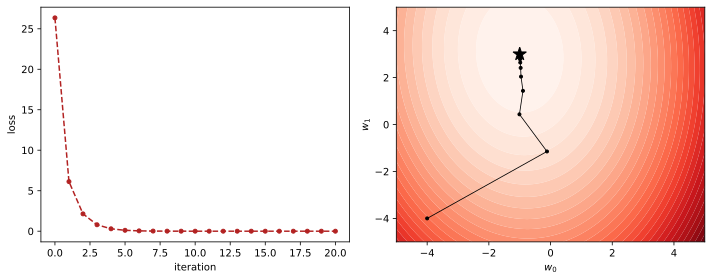

MSE(w_true)       = 1.052e-04
MSE(w after GD)   = 1.052e-04
MSE(pinv)         = 1.052e-04
w_true  = [-1.  3.]
w_pinv  = [-1.0001  2.9999]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

def loss(w, X, y):
    """Mean-squared-error loss."""
    return ((X @ w - y) ** 2).mean()

def grad(w, X, y):
    """Full-batch gradient, vectorized: 2/n * X^T (X w - y)."""
    return 2 / X.shape[0] * X.T @ (X @ w - y)

# Signal: y = -1 + 3 x + noise
n = 1000
X = np.column_stack([np.ones(n), rng.uniform(-1, 1, size=n)])   # <1>
w_true = np.array([-1.0, 3.0])
y = X @ w_true + 0.01 * rng.standard_normal(n)

# Gradient descent from a deliberately bad start
w = np.array([-4.0, -4.0])
eta, epochs = 0.6, 20
w_hist, loss_hist = [w.copy()], [loss(w, X, y)]
for _ in range(epochs):
    w = w - eta * grad(w, X, y)
    w_hist.append(w.copy())
    loss_hist.append(loss(w, X, y))
w_hist = np.array(w_hist)

# Loss landscape over a grid
g = np.linspace(-5, 5, 200)
W0, W1 = np.meshgrid(g, g)
Z = np.array([[loss(np.array([a, b]), X, y) for a in g] for b in g])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(loss_hist, 'o--', color='firebrick', ms=4)
ax[0].set_xlabel('iteration')
ax[0].set_ylabel('loss')
ax[1].contourf(W0, W1, Z, levels=30, cmap='Reds')
ax[1].plot(w_hist[:, 0], w_hist[:, 1], 'k-o', ms=3, lw=0.8)
ax[1].plot(*w_true, 'k*', ms=14)
ax[1].set_xlabel('$w_0$')
ax[1].set_ylabel('$w_1$')
fig.tight_layout()
plt.show()

w_pinv = np.linalg.pinv(X) @ y
print('MSE(w_true)       =', f'{loss(w_true, X, y):.3e}')
print('MSE(w after GD)   =', f'{loss(w_hist[-1], X, y):.3e}')
print('MSE(pinv)         =', f'{loss(w_pinv, X, y):.3e}')
print('w_true  =', w_true)
print('w_pinv  =', np.round(w_pinv, 4))


**Gradient descent on a convex quadratic.**

The annotations: `<1>` prepends a column of ones so the first coefficient is an intercept (the *bias* term). Three quantities deserve comment.

First, gradient descent reaches essentially the same loss as the exact pseudoinverse solution even though it never forms $\mathbf{X}^{+}$; in the right panel, the star marks $\mathbf{w}_{\text{true}}$ and the black path shows the iterates converging to it. Second, the best achievable loss is not zero. The residual $\mathbf{y} - \mathbf{X}\hat{\mathbf{w}}$ at the optimum is the noise with its component along the $d$-dimensional column space removed, so only the $n - d$ complementary directions contribute: its expected squared norm is $(n-d)\sigma^2$. With $n = 1000$ samples, $d = 2$ parameters and $\sigma = 0.01$ the expected loss is $\mathbb{E}[J(\hat{\mathbf{w}})] = \tfrac{n-d}{n}\sigma^2 = 9.98\times 10^{-5}$, and the printed values are a single draw fluctuating around that mean.

Third, because the columns of $\mathbf{X}$ are independent, the minimum is unique and the basin is a single well; the next section shows what changes when they are not.


## Loss surfaces and the rank of $\mathbf{X}$

When the columns of $\mathbf{X}$ are dependent, $\mathbf{X}^{\mathsf T}\mathbf{X}$ is singular, the Hessian has a zero eigenvalue, and the minimizer is no longer unique: the loss is flat along $\mathsf{N}(\mathbf{X})$, so the optimum is a valley rather than a point. The contrast is easiest to see in $d = 2$, where the optimal set is a line. The figure below compares a full-rank design ($\mathbf{X} = [\mathbf{1},\ \mathbf{x}]$) against a rank-one design ($\mathbf{X} = [2\mathbf{x},\ \mathbf{x}]$, so $r = 1 < d = 2$).


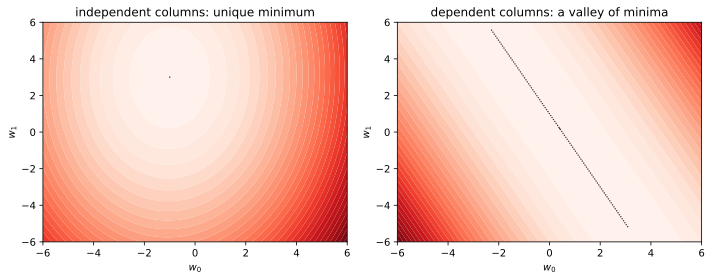

In [3]:
def plot_surface(X, y, ax):
    g = np.linspace(-6, 6, 250)
    W0, W1 = np.meshgrid(g, g)
    Z = np.array([[loss(np.array([a, b]), X, y) for a in g] for b in g])
    ax.contourf(W0, W1, Z, levels=30, cmap='Reds')
    # draw the optimal set  w = pinv(X)y + alpha * v2
    u, s, vt = np.linalg.svd(X, full_matrices=False)
    r = np.count_nonzero(s > 1e-8)
    w0 = np.linalg.pinv(X) @ y
    alphas = np.linspace(-6, 6, 100)
    pts = [w0]                                        # <2> the min-norm solution
    for j in range(r, 2):                             # <3> null-space directions v_{r+1..d}
        pts.extend(w0 + a * vt[j] for a in alphas)
    pts = np.array(pts)
    ax.plot(pts[:, 0], pts[:, 1], 'k.', ms=0.8)
    ax.set_xlabel('$w_0$'); ax.set_ylabel('$w_1$')

n = 1000
x = rng.uniform(-1, 1, size=n)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Independent columns: r = d = 2 -> unique minimum
X_ind = np.column_stack([np.ones(n), x])
y_ind = X_ind @ w_true + 0.01 * rng.standard_normal(n)
plot_surface(X_ind, y_ind, ax[0])
ax[0].set_title('independent columns: unique minimum')

# Dependent columns: r = 1 < d = 2 -> a line of minima
X_dep = np.column_stack([2 * x, x])
y_dep = X_dep @ w_true + 0.01 * rng.standard_normal(n)
plot_surface(X_dep, y_dep, ax[1])
ax[1].set_title('dependent columns: a valley of minima')

fig.tight_layout()
plt.show()


**Unique versus non-unique minima.** The annotations: `<2>` seeds the plot with the min-norm solution $\mathbf{X}^{+}\mathbf{y}$, and `<3>` sweeps the null-space directions $\mathbf{v}_{r+1},\dots,\mathbf{v}_d$ from the SVD to generate the rest of the optimal set. The left panel has independent columns, so $r = d$ and the black dots collapse to a single minimum. The right panel has dependent columns ($\mathbf{x}_1 = 2\mathbf{x}_2$), so the loss is flat along $\mathbf{v}_2$ and the minimizers form a one-dimensional ridge: every point on that line achieves the same loss. This is exactly the affine set $\hat{\mathbf{w}} = \mathbf{X}^{+}\mathbf{y} + \alpha\mathbf{v}_2$ predicted by the SVD solution. Rank deficiency is what makes the normal equations $\mathbf{X}^{\mathsf T}\mathbf{X}\mathbf{w} = \mathbf{X}^{\mathsf T}\mathbf{y}$ singular here, and every point of the ridge is one of their infinitely many solutions.


## Conditioning and convergence

Two numerical lessons follow from the fact that the Hessian is $\mathbf{X}^{\mathsf T}\mathbf{X}$. Its condition number is $\kappa(\mathbf{X}^{\mathsf T}\mathbf{X}) = \kappa(\mathbf{X})^2 = (\sigma_1/\sigma_d)^2$, so a design matrix that is merely *moderately* ill-conditioned produces a *very* ill-conditioned normal-equation system: squaring $\kappa$ doubles its exponent. This is why forming and solving $\mathbf{X}^{\mathsf T}\mathbf{X}$ is discouraged in favor of QR- or SVD-based solvers, which work with $\mathbf{X}$ directly. The same quantity governs gradient descent: on a quadratic with condition number $\kappa$, the best achievable linear convergence rate is $(\kappa - 1)/(\kappa + 1)$, so a large $\kappa(\mathbf{X})$ makes the iterates crawl. Scaling or regularizing the features — replacing $\mathbf{X}^{\mathsf T}\mathbf{X}$ by $\mathbf{X}^{\mathsf T}\mathbf{X} + \lambda\mathbf{I}$ — both improve the condition number, at the cost of a small bias. Regularization is the subject of Chapter 10, where the shifted spectrum of $\mathbf{X}^{\mathsf T}\mathbf{X} + \lambda\mathbf{I}$ is examined directly.


In [4]:
# Condition number governs both solver stability and GD speed.
kappa_gram = lambda X: np.linalg.cond(X) ** 2

for name, X in [('well-scaled', X_ind), ('rank-deficient', X_dep)]:
    g = np.linalg.cond(X)
    print(f'{name:>15}: kappa(X) = {g:10.2e},  kappa(X^T X) = {kappa_gram(X):10.2e}')

# A nearly-collinear design: x2 = x1 + tiny noise
x1 = rng.uniform(-1, 1, size=n)
X_bad = np.column_stack([x1, x1 + 1e-8 * rng.standard_normal(n)])
y_bad = X_bad @ np.array([2.0, -1.0]) + 0.01 * rng.standard_normal(n)
print(f'{"nearly-collinear":>15}: kappa(X) = {np.linalg.cond(X_bad):10.2e},'
      f'  kappa(X^T X) = {kappa_gram(X_bad):10.2e}')


    well-scaled: kappa(X) =   1.75e+00,  kappa(X^T X) =   3.06e+00
 rank-deficient: kappa(X) =   1.02e+16,  kappa(X^T X) =   1.04e+32
nearly-collinear: kappa(X) =   1.15e+08,  kappa(X^T X) =   1.32e+16


The nearly-collinear design has two columns that agree to within $10^{-8}$, so the direction distinguishing them is $10^{-8}$ times as prominent as the common direction, and $\kappa(\mathbf{X}) \approx 10^{8}$. Squaring for the normal equations yields $\kappa(\mathbf{X}^{\mathsf T}\mathbf{X}) \approx 10^{16}$, at the very edge of double-precision resolution. Solving the normal equations for such a matrix would be hopeless, yet the SVD-based pseudoinverse remains accurate because it works directly with $\mathbf{X}$ and never squares the condition number. This single example is the practical justification for preferring $\mathbf{X}^{+}$ over $(\mathbf{X}^{\mathsf T}\mathbf{X})^{-1}\mathbf{X}^{\mathsf T}$.


## Summary

The least-squares solution of $\lVert\mathbf{X}\mathbf{w}-\mathbf{y}\rVert^2$ is the orthogonal projection of $\mathbf{y}$ onto $\mathsf{C}(\mathbf{X})$, and is computed either by the normal equations $\mathbf{X}^{\mathsf T}\mathbf{X}\mathbf{w} = \mathbf{X}^{\mathsf T}\mathbf{y}$ or, more stably, by the pseudoinverse $\hat{\mathbf{w}} = \mathbf{X}^{+}\mathbf{y}$. The objective is a convex quadratic whose Hessian is the Gram matrix $\mathbf{X}^{\mathsf T}\mathbf{X}$; uniqueness of the minimizer is equivalent to $\mathbf{X}$ having independent columns, and otherwise the minima form a $(d-r)$-dimensional affine subspace of the parameter space. Gradient descent finds the minimum iteratively without forming any inverse, converging at a rate set by $\kappa(\mathbf{X})^2$, the same quantity that makes the normal equations numerically fragile. These three views — geometry (projection), algebra (normal equations and the SVD), and optimization (gradient descent on a convex quadratic) — are one theorem seen from three directions.


## Problems

The problems below exercise the least-squares theory, the conditioning of the normal equations, and gradient descent. Problems 1-2 are derivations, Problems 3-4 are numerical, and Problem 5 is a challenge experiment.


### Problem 1 — The expected loss at the optimum

Let $\mathbf X\in\mathbb R^{n\times d}$ have full column rank with $n>d$, and let $\mathbf y=\mathbf X\mathbf w_{\text{true}}+\boldsymbol\varepsilon$, where the entries of $\boldsymbol\varepsilon$ are independent with $\mathbb E[\varepsilon_i]=0$ and $\operatorname{Var}(\varepsilon_i)=\sigma^2$. Let $\hat{\mathbf w}$ be the least-squares solution and $P=\mathbf X(\mathbf X^{\mathsf T}\mathbf X)^{-1}\mathbf X^{\mathsf T}$ the projector onto $\mathsf C(\mathbf X)$.

(a) Show that the residual $\mathbf e=\mathbf y-\mathbf X\hat{\mathbf w}$ satisfies $\mathbf X^{\mathsf T}\mathbf e=\mathbf 0$, so $\mathbf e\perp\mathsf C(\mathbf X)$.

(b) Show that $\mathbf e=(\mathbf I-P)\boldsymbol\varepsilon$. *Hint:* $\mathbf X\hat{\mathbf w}=P\mathbf y$ and $P\mathbf X=\mathbf X$.

(c) Using $\operatorname{tr}P=d$ and $\mathbb E[\boldsymbol\varepsilon\boldsymbol\varepsilon^{\mathsf T}]=\sigma^2\mathbf I$, show that

$$\mathbb E[\lVert\mathbf e\rVert^2]=(n-d)\sigma^2,$$

and hence that the mean-squared-error loss $J(\mathbf w)=\frac1n\lVert\mathbf X\mathbf w-\mathbf y\rVert^2$ satisfies $\mathbb E[J(\hat{\mathbf w})]=\frac{n-d}{n}\sigma^2$, the value the chapter's gradient-descent demo fluctuates around.


### Problem 2 — The geometry of non-uniqueness

Let $\mathbf X\in\mathbb R^{n\times d}$ have rank $r<d$.

(a) Show that if $\hat{\mathbf w}_1,\hat{\mathbf w}_2$ both minimize $\lVert\mathbf X\mathbf w-\mathbf y\rVert^2$, then $\hat{\mathbf w}_1-\hat{\mathbf w}_2\in\mathsf N(\mathbf X)$. *Hint:* both satisfy the normal equations, and $\mathsf N(\mathbf X^{\mathsf T}\mathbf X)=\mathsf N(\mathbf X)$.

(b) Using the SVD $\mathbf X=\mathbf U\boldsymbol\Sigma\mathbf V^{\mathsf T}$, write an arbitrary minimizer as $\mathbf w=\mathbf X^{+}\mathbf y+\sum_{j=r+1}^{d}\alpha_j\mathbf v_j$ and show that

$$\lVert\mathbf w\rVert^2=\lVert\mathbf X^{+}\mathbf y\rVert^2+\sum_{j=r+1}^{d}\alpha_j^2.$$

Conclude that the minimum-norm minimizer is $\mathbf X^{+}\mathbf y$.

(c) Conclude that the set of minimizers is the affine subspace $\mathbf X^{+}\mathbf y+\mathsf N(\mathbf X)$ of dimension $d-r$.


### Problem 3 — Normal equations vs pseudoinverse

The chapter's nearly-collinear design has $\mathbf x_2=\mathbf x_1+10^{-8}\cdot$ noise, giving $\kappa(\mathbf X)\approx 10^8$ and $\kappa(\mathbf X^{\mathsf T}\mathbf X)\approx 10^{16}$. This problem compares the normal equations against the pseudoinverse on that design.

(a) Build the design and solve for $\mathbf w$ three ways: the normal equations `np.linalg.solve(X.T @ X, X.T @ y)`, the pseudoinverse `np.linalg.pinv(X) @ y`, and `np.linalg.lstsq`. Report $\kappa(\mathbf X)$, $\kappa(\mathbf X^{\mathsf T}\mathbf X)$, and their ratio.

(b) Compare the solutions: the relative difference $\lVert\mathbf w_{\text{ne}}-\mathbf w_{\text{pinv}}\rVert/\lVert\mathbf w_{\text{pinv}}\rVert$ should be large, because the weights are not identifiable when the columns are nearly collinear, while `lstsq` should agree with the pseudoinverse to machine precision.

(c) Compare the losses $J(\mathbf w)=\frac1n\lVert\mathbf X\mathbf w-\mathbf y\rVert^2$ at the three solutions: all sit near the minimum, showing that a wildly wrong $\mathbf w$ can still fit well.

The starter code builds the data; fill in the measurements.


In [1]:
import numpy as np

rng = np.random.default_rng(3)
n = 1000
x1 = rng.uniform(-1, 1, size=n)
X = np.column_stack([x1, x1 + 1e-8 * rng.standard_normal(n)])
w_true = np.array([2.0, -1.0])
y = X @ w_true + 0.01 * rng.standard_normal(n)

# (a) kappa(X), kappa(X^T X), and their ratio
# (b) w_ne, w_pinv, w_lstsq; relative differences
# (c) losses J(w) = ((X @ w - y) ** 2).mean() for each solution


### Problem 4 — Gradient descent: rate vs condition number

The chapter states that on a quadratic with Hessian condition number $\kappa$, gradient descent with the optimal step converges at the linear rate $(\kappa-1)/(\kappa+1)$. This problem verifies that rate numerically on a design with prescribed singular values.

(a) Build $\mathbf X=\mathbf U\operatorname{diag}(\sigma_1,\dots,\sigma_d)\mathbf V^{\mathsf T}$ with $n=300$, $d=6$, and singular values log-spaced from $1$ to $1/\kappa(\mathbf X)$ with $\kappa(\mathbf X)=10$. The Hessian of $J(\mathbf w)=\frac1n\lVert\mathbf X\mathbf w-\mathbf y\rVert^2$ is $\frac2n\mathbf X^{\mathsf T}\mathbf X$, so $\kappa(\nabla^2 J)=\kappa(\mathbf X)^2=100$ and the predicted rate is $99/101\approx 0.9802$.

(b) Run gradient descent from $\mathbf w^{(0)}=\mathbf 0$ with the optimal step $\eta=2/(\lambda_{\max}+\lambda_{\min})$, where $\lambda_{\max},\lambda_{\min}$ are the extreme eigenvalues of $\frac2n\mathbf X^{\mathsf T}\mathbf X$. Record $\lVert\mathbf w^{(t)}-\hat{\mathbf w}\rVert$ against the exact solution $\hat{\mathbf w}=\mathbf X^{+}\mathbf y$, and estimate the empirical contraction factor $\hat\rho=(\lVert\mathbf w^{(T)}-\hat{\mathbf w}\rVert/\lVert\mathbf w^{(0)}-\hat{\mathbf w}\rVert)^{1/T}$.

(c) Compare $\hat\rho$ with $(\kappa-1)/(\kappa+1)$, and confirm that the step $\eta=2.5/\lambda_{\max}$, past the stability limit $2/\lambda_{\max}$, makes the iterates diverge.

The starter code builds the design; fill in the descent loop and the measurements.


In [1]:
import numpy as np

rng = np.random.default_rng(5)
n, d, kappa = 300, 6, 10.0
sig = np.geomspace(1.0, 1.0 / kappa, d)
U, _ = np.linalg.qr(rng.standard_normal((n, d)))
V, _ = np.linalg.qr(rng.standard_normal((d, d)))
X = U @ np.diag(sig) @ V.T
w_true = rng.standard_normal(d)
y = X @ w_true
w_star = np.linalg.pinv(X) @ y

# (a) lambda_max, lambda_min of (2/n) X^T X; predicted rate (kappa - 1) / (kappa + 1)
# (b) gradient descent with eta = 2 / (lambda_max + lambda_min); empirical rate
# (c) divergence with eta = 2.5 / lambda_max


### Problem 5 — Three solvers under growing κ

**Challenge.** The chapter warns that the normal equations square the condition number. This experiment measures the price directly: for designs with $\kappa(\mathbf X)$ ranging over $10^2,\dots,10^8$, compare the accuracy of three solvers on the same exact problem $\mathbf y=\mathbf X\mathbf w_{\text{true}}$ with no noise, so the minimum loss is zero and every error is solver error.

(a) For each $\kappa$, build $\mathbf X=\mathbf U\operatorname{diag}(\sigma_1,\dots,\sigma_d)\mathbf V^{\mathsf T}$ with $n=100$, $d=10$, and singular values log-spaced from $1$ to $1/\kappa$, and solve via the normal equations, `np.linalg.lstsq` (QR), and `np.linalg.pinv` (SVD). Record the relative error $\lVert\hat{\mathbf w}-\mathbf w_{\text{true}}\rVert/\lVert\mathbf w_{\text{true}}\rVert$ for each solver.

(b) Fit log-log slopes of error versus $\kappa$ for the normal equations and for QR. The theory predicts $\operatorname{err}_{\text{ne}}\sim\kappa^2$ (slope $2$) and $\operatorname{err}_{\text{qr}}\sim\kappa$ (slope $1$).

(c) Verify that the residual $\lVert\mathbf X\hat{\mathbf w}-\mathbf y\rVert$ stays small for both solvers at every $\kappa$: residual quality does not discriminate the solvers, weight accuracy does.

The starter code sets up the loop; fill in the solves and the slope fits.


In [1]:
import numpy as np

rng = np.random.default_rng(9)
n, d = 100, 10
w_true = rng.standard_normal(d)
kappas = [1e2, 1e4, 1e6, 1e8]

# for each kappa:
#   sig = np.geomspace(1.0, 1.0 / kappa, d)
#   U, _ = np.linalg.qr(rng.standard_normal((n, d)))
#   V, _ = np.linalg.qr(rng.standard_normal((d, d)))
#   X = U @ np.diag(sig) @ V.T
#   y = X @ w_true
#   solve via normal equations, np.linalg.lstsq(X, y, rcond=None), np.linalg.pinv(X) @ y
#   record relative error and residual for each solver
# fit log-log slopes of error vs kappa for the normal equations and lstsq
